Price Distribution Plot

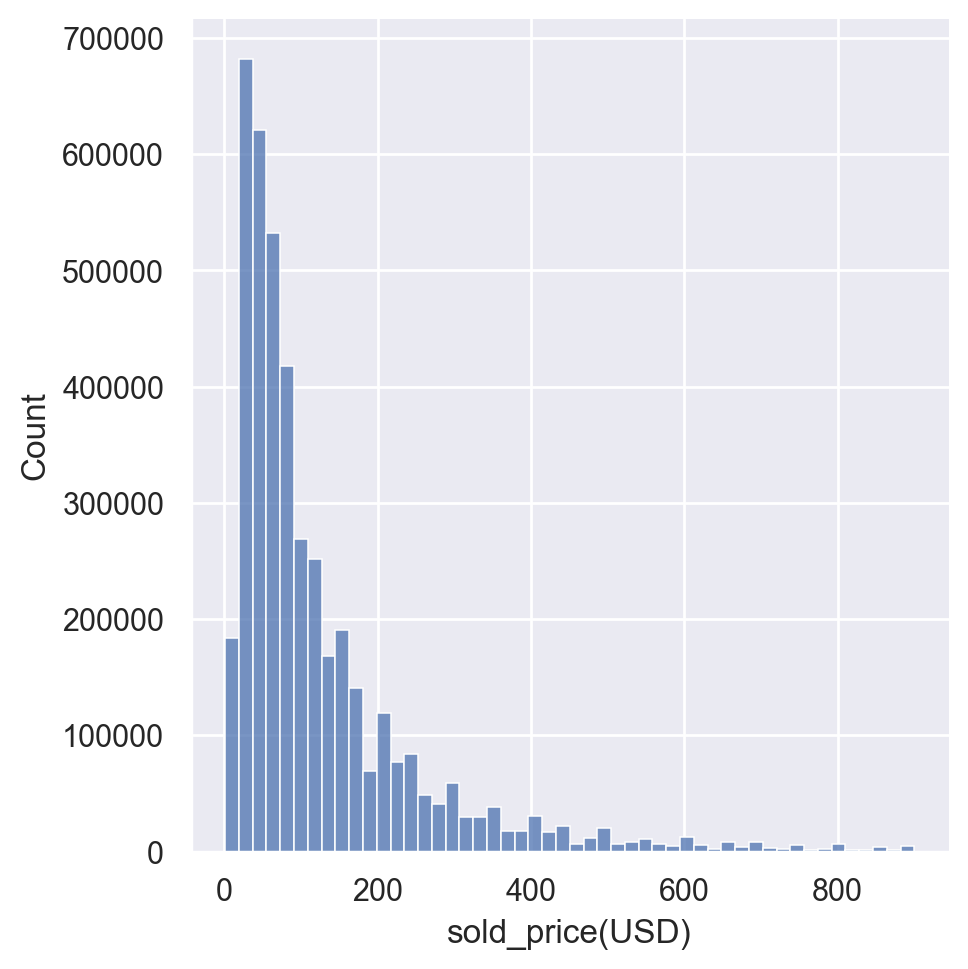

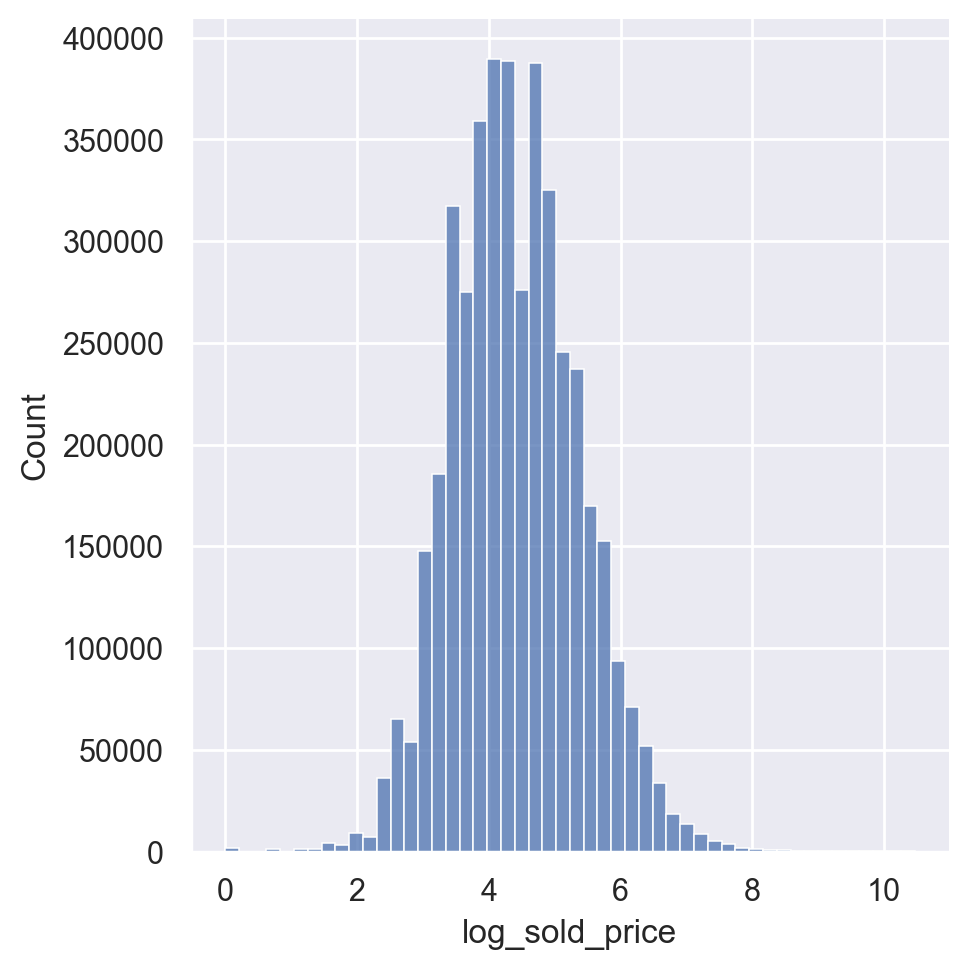

In [26]:
import seaborn as sns
import polars as pl
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

sns.set_theme()
df = pl.scan_parquet('../data/parquets/sold_listings_20260901.parquet').lazy()

def price_distribution_plots(df: pl.LazyFrame):
    threshold = df.select(pl.col('sold_price')).quantile(0.99).collect().item()
    prices = df.filter(pl.col('sold_price') <= threshold).select(pl.col('sold_price').alias('sold_price(USD)')).collect().to_pandas()
    log_prices = df.select(pl.col('sold_price').log().alias('log_sold_price')).collect().to_pandas()
    plot1 = sns.displot(prices, x="sold_price(USD)", bins=50)
    plot2 = sns.displot(log_prices, x="log_sold_price", bins=50)
    plot1.savefig("../data/plots/price_distribution.png", dpi=300)
    plot2.savefig("../data/plots/log_price_distribution.png", dpi=300)

price_distribution_plots(df)